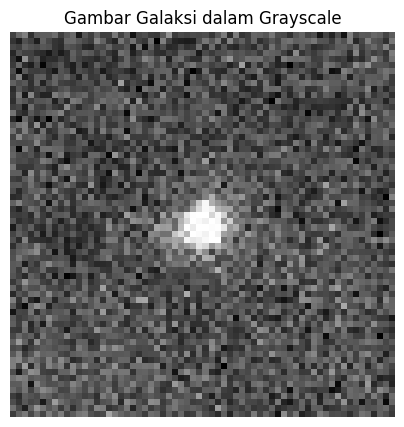

In [ ]:
# Konversi ke Grayscale
from email.mime import image

from matplotlib import pyplot as plt


gray_image = image.convert("L")

plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.title("Gambar Galaksi dalam Grayscale")
plt.show()

In [ ]:
# Mengubah gambar menjadi array pixel

import numpy as np


pixel_array = np.array(gray_image)

print("Shape:", pixel_array.shape)
print("Pixel minimum:", pixel_array.min())
print("Pixel maksimum:", pixel_array.max())
print("Pixel rata-rata:", pixel_array.mean())

Shape: (64, 64)
Pixel minimum: 0
Pixel maksimum: 255
Pixel rata-rata: 82.550048828125


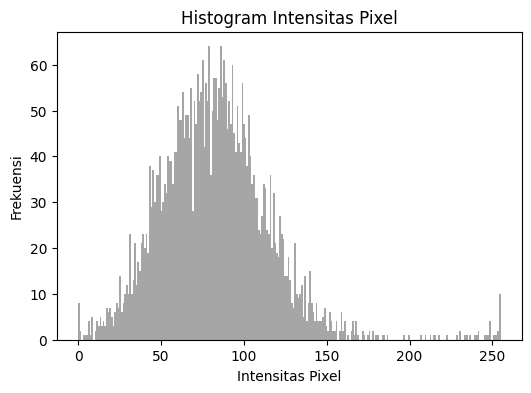

In [4]:
# Histogram Intensitas Pixel

plt.figure(figsize=(6, 4))
plt.hist(pixel_array.ravel(), bins=256, color='gray', alpha=0.7)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.title('Histogram Intensitas Pixel')
plt.show()

In [5]:
# Normalisasi Intensitas Pixel
normalized_pixel_array = pixel_array / 255.0

print("Pixel minimum setelah normalisasi:", normalized_pixel_array.min())
print("Pixel maksimum setelah normalisasi:", normalized_pixel_array.max())

Pixel minimum setelah normalisasi: 0.0
Pixel maksimum setelah normalisasi: 1.0


In [ ]:
# Ekstraksi Fitur Histogram dari Gambar
import os
from tkinter import image_names

import pandas as pd


features = []

for file in image_names:

    image = Image.open(file).convert("L")
    pixels = np.array(image)
    
    features.append({
        "filename": os.path.basename(file),
        "mean": pixels.mean(),
        "std": pixels.std(),
        "min": pixels.min(),
        "max": pixels.max()
    })

# Mengubah hasil menjadi dataframe
features_df = pd.DataFrame(features)
print("Hasil ekstraksi fitur:")
display(features_df.head())

Hasil ekstraksi fitur:


,filename,mean,std,min,max
0,grb0422a_01_1013_1727_3.jpg,82.550049,33.741296,0,255
1,grb0422a_01_1035_1991_3.jpg,112.039062,28.826638,5,255
2,grb0422a_01_257_154_3.jpg,95.445068,35.650894,0,255
3,IC3521-H01_1260_751_3.jpg,91.513184,35.072502,0,255
4,IC3521-H01_1300_759_3.jpg,114.273193,40.021794,0,255


In [7]:
# Statistik Hasil Pengolahan

display(features_df.describe())

,mean,std,min,max
count,942.000000,942.000000,942.000000,942.000000
mean,91.640527,35.619896,0.163482,254.773885
std,9.830205,5.305823,0.949760,1.116411
min,64.350830,23.486716,0.000000,243.000000
25%,85.457886,32.250488,0.000000,255.000000
50%,89.949707,34.441276,0.000000,255.000000
75%,95.503052,37.259825,0.000000,255.000000
max,150.686279,67.182238,13.000000,255.000000


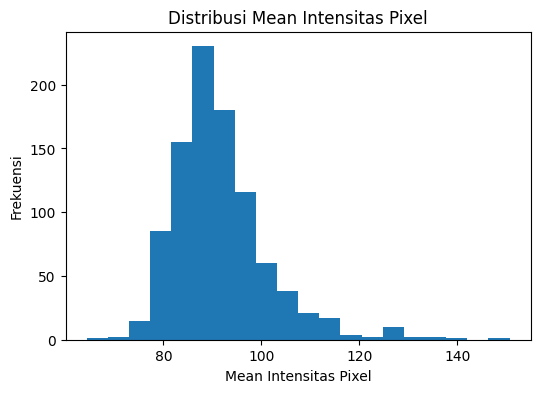

In [8]:
# Distribusi Mean Intensitas Pixel
plt.figure(figsize=(6, 4))

plt.hist(features_df["mean"], bins=20)

plt.title("Distribusi Mean Intensitas Pixel")
plt.xlabel("Mean Intensitas Pixel")
plt.ylabel("Frekuensi")

plt.show()